In [1]:
#pip install kagglehub

In [2]:
import kagglehub

#kaggle dan veri çektik
# Download latest version
path = kagglehub.dataset_download("fronkongames/steam-games-dataset")

print("Path to dataset files:", path)

Path to dataset files: /Users/tugce/.cache/kagglehub/datasets/fronkongames/steam-games-dataset/versions/49


In [3]:
import os

#path in içindeki dosyaları listeledik
print(os.listdir(path))

['games.json', 'games.csv', 'games_clean.csv']


In [4]:
import numpy as np
import pandas as pd

#csv dosyasını okuduk
#ilk column u indeks olarak almadığı için kayma vardı index_col koduyla ilk column u index olarak almamasını söyledik
df = pd.read_csv(os.path.join(path, 'games.csv'), index_col = False)
df.head(20)

,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,DiscountDLC count,About the game,Supported languages,...,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
0,2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,NaN,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...
1,496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",...,8,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...
2,1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...",...,0,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...
3,3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",...,0,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...
4,3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,Its not just a Maze; its a Quest! Enter the ca...,...,0,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...
5,1654170,Agony VR,"Apr 5, 2023",0 - 20000,0,0,13.99,0,0,A JOURNEY THROUGH HELL! Explore the most terri...,...,0,0,0,0,Ignibit,"Ignibit,Madmind Studio","Single-player,Tracked Controller Support,VR On...","Action,Adventure",NaN,https://shared.akamai.steamstatic.com/store_it...
6,1934300,Armored Brigade II,"Apr 8, 2025",0 - 20000,8,0,35.99,10,1,Building on the success of its acclaimed prede...,...,675,0,1253,0,Veitikka Studios,Matrix Games,"Single-player,Steam Workshop,Steam Cloud,Famil...","Simulation,Strategy","Simulation,Strategy,RTS,Wargame,Grand Strategy...",https://shared.akamai.steamstatic.com/store_it...
7,700340,Galacatraz: Eject Equip Escape,"Feb 1, 2018",0 - 20000,0,0,0.99,0,0,"Years ago, Ricardo Luger was in the wrong plac...",...,0,0,0,0,Summer Bear Studio,Summer Bear Studio,"Single-player,Full controller support,Family S...","Action,Indie",NaN,https://shared.akamai.steamstatic.com/store_it...
8,1157670,Hepta Beats,"May 7, 2021",0 - 20000,0,0,0.99,0,0,Hepta Beats is a 2D side-view platformer game ...,...,0,0,0,0,Matheus Bigatão,Matheus Bigatão,"Single-player,Steam Achievements,Full controll...","Casual,Indie","Precision Platformer,Rhythm,Music,Difficult,Ab...",https://shared.akamai.steamstatic.com/store_it...
9,1540330,MUMBA IV: Egypt Jewels,"Dec 13, 2021",0 - 20000,1,0,0.59,0,1,WARRNING Don't show Your mom this game. You kn...,...,0,0,0,0,Airem,Airem,"Single-player,Steam Achievements,Full controll...","Action,Casual,Indie,Strategy","Casual,Action,Strategy,Puzzle,Match 3,Singlepl...",https://shared.akamai.steamstatic.com/store_it...


Görüldüğü gibi 'DiscountDLC count' bu iki column birleşmiş gözüküyor Datasette bir hata var.
O yüzden dataseti okumadan önce bu hatayı düzeltiyoruz.

In [5]:
#Headerları yazdırdık
file_path = os.path.join(path, "games.csv")

# İlk satırı oku
with open(file_path, "r", encoding="utf-8") as f:
    header = f.readline()

print(header)

AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,DiscountDLC count,About the game,Supported languages,Full audio languages,Reviews,Header image,Website,Support url,Support email,Windows,Mac,Linux,Metacritic score,Metacritic url,User score,Positive,Negative,Score rank,Achievements,Recommendations,Notes,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies



In [6]:
with open(file_path, "r", encoding="utf-8") as f:
    lines = f.readlines()
# Sadece header'ı düzelt
lines[0] = lines[0].replace(
    "DiscountDLC count",
    "Discount,DLC count"
)

# Düzeltilmiş CSV'yi yeni dosyaya yaz
clean_file = os.path.join(path, "games_clean.csv")

with open(clean_file, "w", encoding="utf-8") as f:
    f.writelines(lines)

# Temizlenmiş dosyayı oku
df = pd.read_csv(clean_file)

print(df.columns.tolist())

['AppID', 'Name', 'Release date', 'Estimated owners', 'Peak CCU', 'Required age', 'Price', 'Discount', 'DLC count', 'About the game', 'Supported languages', 'Full audio languages', 'Reviews', 'Header image', 'Website', 'Support url', 'Support email', 'Windows', 'Mac', 'Linux', 'Metacritic score', 'Metacritic url', 'User score', 'Positive', 'Negative', 'Score rank', 'Achievements', 'Recommendations', 'Notes', 'Average playtime forever', 'Average playtime two weeks', 'Median playtime forever', 'Median playtime two weeks', 'Developers', 'Publishers', 'Categories', 'Genres', 'Tags', 'Screenshots', 'Movies']


In [7]:
df.head(20)

,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,...,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
0,2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,NaN,...,0,0,0,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
1,496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",...,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...,NaN
2,1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...",...,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...,NaN
3,3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",...,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
4,3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,Its not just a Maze; its a Quest! Enter the ca...,...,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
5,1654170,Agony VR,"Apr 5, 2023",0 - 20000,0,0,13.99,0,0,A JOURNEY THROUGH HELL! Explore the most terri...,...,0,0,0,Ignibit,"Ignibit,Madmind Studio","Single-player,Tracked Controller Support,VR On...","Action,Adventure",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
6,1934300,Armored Brigade II,"Apr 8, 2025",0 - 20000,8,0,35.99,10,1,Building on the success of its acclaimed prede...,...,0,1253,0,Veitikka Studios,Matrix Games,"Single-player,Steam Workshop,Steam Cloud,Famil...","Simulation,Strategy","Simulation,Strategy,RTS,Wargame,Grand Strategy...",https://shared.akamai.steamstatic.com/store_it...,NaN
7,700340,Galacatraz: Eject Equip Escape,"Feb 1, 2018",0 - 20000,0,0,0.99,0,0,"Years ago, Ricardo Luger was in the wrong plac...",...,0,0,0,Summer Bear Studio,Summer Bear Studio,"Single-player,Full controller support,Family S...","Action,Indie",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
8,1157670,Hepta Beats,"May 7, 2021",0 - 20000,0,0,0.99,0,0,Hepta Beats is a 2D side-view platformer game ...,...,0,0,0,Matheus Bigatão,Matheus Bigatão,"Single-player,Steam Achievements,Full controll...","Casual,Indie","Precision Platformer,Rhythm,Music,Difficult,Ab...",https://shared.akamai.steamstatic.com/store_it...,NaN
9,1540330,MUMBA IV: Egypt Jewels,"Dec 13, 2021",0 - 20000,1,0,0.59,0,1,WARRNING Don't show Your mom this game. You kn...,...,0,0,0,Airem,Airem,"Single-player,Steam Achievements,Full controll...","Action,Casual,Indie,Strategy","Casual,Action,Strategy,Puzzle,Match 3,Singlepl...",https://shared.akamai.steamstatic.com/store_it...,NaN


In [8]:
df.shape

(125855, 40)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125855 entries, 0 to 125854
Data columns (total 40 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   AppID                       125855 non-null  int64  
 1   Name                        125854 non-null  object 
 2   Release date                125855 non-null  object 
 3   Estimated owners            125855 non-null  object 
 4   Peak CCU                    125855 non-null  int64  
 5   Required age                125855 non-null  int64  
 6   Price                       125855 non-null  float64
 7   Discount                    125855 non-null  int64  
 8   DLC count                   125855 non-null  int64  
 9   About the game              117393 non-null  object 
 10  Supported languages         125855 non-null  object 
 11  Full audio languages        125855 non-null  object 
 12  Reviews                     12181 non-null   object 
 13  Header image  

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
AppID,125855.0,2.032627e+06,1.117434e+06,10.0,1083495.00,1949010.00,2938410.000,4437540.00
Peak CCU,125855.0,5.318720e+01,3.681083e+03,0.0,0.00,0.00,0.000,1013936.00
Required age,125855.0,1.653649e-01,1.642666e+00,0.0,0.00,0.00,0.000,21.00
Price,125855.0,4.811174e+00,1.248933e+01,0.0,0.59,2.39,5.545,999.98
Discount,125855.0,1.789683e+01,2.862852e+01,0.0,0.00,0.00,37.000,100.00
DLC count,125855.0,5.354336e-01,1.432842e+01,0.0,0.00,0.00,0.000,3703.00
Metacritic score,125855.0,2.500083e+00,1.349292e+01,0.0,0.00,0.00,0.000,97.00
User score,125855.0,2.391641e-02,1.376811e+00,0.0,0.00,0.00,0.000,100.00
Positive,125855.0,1.018182e+03,2.772782e+04,0.0,0.00,4.00,35.000,7642084.00
Negative,125855.0,1.648786e+02,5.305001e+03,0.0,0.00,1.00,10.000,1173003.00


In [11]:
df.Price.T

0          0.00
1          5.24
2          4.99
3          8.99
4          4.99
          ...  
125850     8.09
125851     0.59
125852    12.99
125853     9.99
125854     2.51
Name: Price, Length: 125855, dtype: float64

In [12]:
df.Genres.T

0                             NaN
1                       Adventure
2                          Casual
3         Casual,Indie,Simulation
4             Action,Early Access
                   ...           
125850           Indie,Simulation
125851              Adventure,RPG
125852     Action,Adventure,Indie
125853           Action,Adventure
125854     Action,Adventure,Indie
Name: Genres, Length: 125855, dtype: object

In [13]:
df.Genres.unique()

array([nan, 'Adventure', 'Casual', ...,
       'Simulation,Free To Play,Accounting,Education,Software Training,Early Access',
       'Casual,Sports,Strategy,Education,Software Training',
       'Action,Indie,Massively Multiplayer,Racing,Sports'], dtype=object)

In [14]:
df.Genres.nunique()

2922

In [15]:
df.sort_values(by="Price", ascending=False)

,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,...,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
41088,2504210,The Leverage Game Business Edition,"Aug 26, 2023",0 - 20000,0,0,999.98,0,0,The Leverage Game is a board game in which pla...,...,0,0,0,A&S Inc.,A&S Inc.,"Single-player,Multi-player,PvP,Family Sharing","Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
68275,2499620,The Leverage Game,"Aug 25, 2023",0 - 20000,0,0,999.98,0,0,The Leverage Game is a board game in which pla...,...,0,0,0,A&S Inc.,A&S Inc.,"Single-player,Multi-player,PvP,Online PvP,Fami...","Indie,Simulation","Board Game,Turn-Based Tactics,Simulation,Educa...",https://shared.akamai.steamstatic.com/store_it...,NaN
34463,1200520,Ascent Free-Roaming VR Experience,"Dec 27, 2019",0 - 20000,0,0,999.00,0,0,Please note that this game requires a play spa...,...,0,0,0,Fury VR,Zenland Video Games,"Single-player,Multi-player,Co-op,LAN Co-op,Tra...",Action,"Action,Hentai,Nudity,Sexual Content,LGBTQ+,VR,...",https://shared.akamai.steamstatic.com/store_it...,NaN
31935,3013840,True Love,"Jun 27, 2024",0 - 20000,0,0,500.00,0,0,This game created out of pure sadness. I have ...,...,0,0,0,A Guy,Whoes heart broken,"Single-player,Family Sharing","Action,Adventure,Casual,Indie","Casual,Action-Adventure,Visual Novel,Dating Si...",https://shared.akamai.steamstatic.com/store_it...,NaN
77652,1105450,Aartform Curvy 3D 4.0,"Jan 20, 2020",0 - 20000,0,0,299.99,0,0,Curvy 3D 4.0 is an innovative sculpting progra...,...,0,0,0,Aartform Ltd,Aartform Ltd,NaN,"Animation & Modeling,Design & Illustration","Design & Illustration,Animation & Modeling,3D",https://shared.akamai.steamstatic.com/store_it...,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48389,2450420,Last Hope Playtest,"Dec 21, 2023",0 - 0,0,0,0.00,0,0,NaN,...,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100131,3112490,Death Report,"Nov 1, 2024",0 - 0,0,0,0.00,0,0,NaN,...,0,0,0,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
48390,1895060,Indy Pro '22: Rebirth of the Territories Playtest,"Feb 17, 2022",0 - 0,0,0,0.00,0,0,NaN,...,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
48394,2018830,Twin Cores,"Sep 14, 2022",0 - 0,0,0,0.00,0,0,Emergency calls echo throughout the C2 Terrafo...,...,0,0,0,Starskeeper,Starskeeper,"Multi-player,Co-op,Shared/Split Screen Co-op,S...",Action,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN


In [16]:
df.set_index("Name")

,AppID,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,Supported languages,...,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
Name,,,,,,,,,,,,,,,,,,,,,
Black Dragon Mage Playtest,2539430,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,NaN,[],...,0,0,0,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
Supipara - Chapter 1 Spring Has Come!,496350,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",['English'],...,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...,NaN
Mystery Solitaire The Black Raven,1034400,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...","['English', 'French', 'German', 'Russian']",...,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...,NaN
버튜버 파라노이아 - Vtuber Paranoia,3292190,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",['Korean'],...,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
Maze Quest VR,3631080,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,Its not just a Maze; its a Quest! Enter the ca...,['English'],...,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Sotsugyo Omedeto,3249570,"Mar 1, 2026",0 - 0,0,0,8.09,0,0,A survival trial game set in an all-girls scho...,"['English', 'Japanese', 'Korean', 'Simplified ...",...,0,0,0,SuperLoki,SuperLoki,"Single-player,Steam Achievements,Camera Comfor...","Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
Island on cloud,2218150,"Feb 24, 2026",0 - 0,0,0,0.59,0,0,"A game with a quirky art style, resembling ani...","['English', 'Simplified Chinese']",...,0,0,0,7th Ghost,7th Ghost,"Single-player,Family Sharing","Adventure,RPG",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
Rosie Planet,3788650,"Mar 1, 2026",0 - 0,0,0,12.99,0,0,Jam Packed full with Videogame Rosie Planet is...,['English'],...,0,0,0,Connor Leary,Connor Leary,"Single-player,Full controller support,Playable...","Action,Adventure,Indie",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN


In [17]:
action_games = df[df["Genres"] == "Action"]
action_games.head()

,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,...,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
16,2517090,Challenge from the Black Cat,"Aug 10, 2023",0 - 20000,0,0,1.40,0,0,A block breaking game with a cat motif . The g...,...,0,0,0,ZENO,ZENO,"Single-player,Partial Controller Support,Famil...",Action,"Action,Shooter,Puzzle,Puzzle-Platformer,Cute,R...",https://shared.akamai.steamstatic.com/store_it...,NaN
30,1514380,COGEN: Sword of Rewind / COGEN: 大鳥こはくと刻の剣,"Jan 26, 2022",20000 - 50000,0,0,12.49,0,3,■Defy Death by Rewinding Time! Any hit you tak...,...,0,0,0,"Gemdrops, Inc.","Gemdrops, Inc.","Single-player,Steam Achievements,Full controll...",Action,"Action-Adventure,Pixel Graphics,Time Manipulat...",https://shared.akamai.steamstatic.com/store_it...,NaN
39,2731180,Blaster Multiplayer,"Jan 2, 2024",0 - 0,0,0,0.00,0,0,About This Game Overview: Immerse yourself in ...,...,0,0,0,Guillaume Norgol,Guillaume Norgol,"Multi-player,PvP,Online PvP,Full controller su...",Action,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
40,1186670,Fateless,"Nov 28, 2019",100000 - 200000,0,0,0.00,0,0,FPS game in which you defend Earth from monste...,...,0,0,0,Dimitri Lozovoy,Dimitri Lozovoy,"Single-player,Partial Controller Support",Action,"Action,Shooter,FPS,Free to Play",https://shared.akamai.steamstatic.com/store_it...,NaN
83,3050490,TIMEGAL HD-Remaster,"Apr 9, 2025",0 - 20000,1,0,14.99,0,0,"Encounter dinosaurs, cavemen, pirates, gladiat...",...,0,0,0,TAITO CORP.,TAITO CORP.,"Single-player,Steam Achievements,Full controll...",Action,"Action,Arcade,2D,Anime,Cute,Cartoon,Hand-drawn...",https://shared.akamai.steamstatic.com/store_it...,NaN


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125855 entries, 0 to 125854
Data columns (total 40 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   AppID                       125855 non-null  int64  
 1   Name                        125854 non-null  object 
 2   Release date                125855 non-null  object 
 3   Estimated owners            125855 non-null  object 
 4   Peak CCU                    125855 non-null  int64  
 5   Required age                125855 non-null  int64  
 6   Price                       125855 non-null  float64
 7   Discount                    125855 non-null  int64  
 8   DLC count                   125855 non-null  int64  
 9   About the game              117393 non-null  object 
 10  Supported languages         125855 non-null  object 
 11  Full audio languages        125855 non-null  object 
 12  Reviews                     12181 non-null   object 
 13  Header image  

In [19]:
df.Categories

0                                                       NaN
1         Single-player,Steam Trading Cards,Steam Cloud,...
2                              Single-player,Family Sharing
3           Single-player,Steam Achievements,Family Sharing
4         Single-player,VR Only,Steam Leaderboards,Famil...
                                ...                        
125850    Single-player,Steam Achievements,Camera Comfor...
125851                         Single-player,Family Sharing
125852    Single-player,Full controller support,Playable...
125853    Single-player,Steam Achievements,Full controll...
125854    Single-player,Steam Achievements,Full controll...
Name: Categories, Length: 125855, dtype: object

In [20]:
df.Categories.str.contains("Single-player").isna().sum()

np.int64(8966)

In [27]:
df.Categories.str.contains("Single-player", na=False)

0         False
1          True
2          True
3          True
4          True
          ...  
125850     True
125851     True
125852     True
125853     True
125854     True
Name: Categories, Length: 125855, dtype: bool

In [30]:
df[df.Categories.str.contains("Single-player", na=False)]

,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,...,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
1,496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",...,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...,NaN
2,1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...",...,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...,NaN
3,3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",...,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
4,3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,Its not just a Maze; its a Quest! Enter the ca...,...,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
5,1654170,Agony VR,"Apr 5, 2023",0 - 20000,0,0,13.99,0,0,A JOURNEY THROUGH HELL! Explore the most terri...,...,0,0,0,Ignibit,"Ignibit,Madmind Studio","Single-player,Tracked Controller Support,VR On...","Action,Adventure",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125850,3249570,Sotsugyo Omedeto,"Mar 1, 2026",0 - 0,0,0,8.09,0,0,A survival trial game set in an all-girls scho...,...,0,0,0,SuperLoki,SuperLoki,"Single-player,Steam Achievements,Camera Comfor...","Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
125851,2218150,Island on cloud,"Feb 24, 2026",0 - 0,0,0,0.59,0,0,"A game with a quirky art style, resembling ani...",...,0,0,0,7th Ghost,7th Ghost,"Single-player,Family Sharing","Adventure,RPG",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
125852,3788650,Rosie Planet,"Mar 1, 2026",0 - 0,0,0,12.99,0,0,Jam Packed full with Videogame Rosie Planet is...,...,0,0,0,Connor Leary,Connor Leary,"Single-player,Full controller support,Playable...","Action,Adventure,Indie",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
125853,3509140,Fear Effect 2: Retro Helix,"Feb 27, 2026",0 - 0,0,0,9.99,0,0,Return to 2048 Hong Kong in the groundbreaking...,...,0,0,0,Implicit Conversions,Limited Run Games,"Single-player,Steam Achievements,Full controll...","Action,Adventure",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN


In [31]:
df.Categories.str.contains("VR Only", na=False)

0         False
1         False
2         False
3         False
4          True
          ...  
125850    False
125851    False
125852    False
125853    False
125854    False
Name: Categories, Length: 125855, dtype: bool

In [32]:
df[df.Categories.str.contains("VR Only", na=False)]

,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,...,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
4,3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,Its not just a Maze; its a Quest! Enter the ca...,...,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
5,1654170,Agony VR,"Apr 5, 2023",0 - 20000,0,0,13.99,0,0,A JOURNEY THROUGH HELL! Explore the most terri...,...,0,0,0,Ignibit,"Ignibit,Madmind Studio","Single-player,Tracked Controller Support,VR On...","Action,Adventure",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
22,815170,Zombie World,"Jun 1, 2018",0 - 20000,0,0,7.99,0,0,"Zombie world A dead city occupied by zombies, ...",...,0,0,0,M.R.Studio,M.R.Studio,"Single-player,Multi-player,PvP,Online PvP,Trac...","Action,Adventure,Indie,RPG","Indie,Action,Adventure,RPG,VR",https://shared.akamai.steamstatic.com/store_it...,NaN
27,657010,Lucky Night: Texas Hold'em VR,"Jul 26, 2017",100000 - 200000,0,0,0.00,0,0,Server closing of Lucky Night To all the playe...,...,0,121,0,ATC Games,ATC Games,"Multi-player,PvP,Online PvP,Tracked Controller...","Casual,Free To Play","Free to Play,Casual,VR",https://shared.akamai.steamstatic.com/store_it...,NaN
31,496910,DrumKit VR - Play drum kit in the world of VR,"Jul 8, 2016",0 - 20000,0,0,4.99,0,0,' DrumKit VR ' is a VR game lets you play drum...,...,0,0,0,0o0,0o0,"Tracked Controller Support,VR Only",Audio Production,"Audio Production,VR",https://shared.akamai.steamstatic.com/store_it...,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125749,4257240,Paper Craft,"Feb 26, 2026",0 - 0,0,0,19.99,0,0,Paper Craft is a made for VR 3D platformer set...,...,0,0,0,Solar Eye LLC,Solar Eye LLC,"Single-player,Steam Achievements,Tracked Contr...","Action,Adventure,Indie",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
125799,4318300,Dino VR Experience,"Feb 28, 2026",0 - 0,0,0,6.99,0,0,Dino VR Museum is an immersive VR experience t...,...,0,0,0,Virtual Factory srl,Virtual factory srl,"Single-player,VR Only,Playable without Timed I...","Simulation,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
125815,3675840,Snow Defense,"Feb 27, 2026",0 - 0,0,0,5.59,0,0,Dynamic VR gameplay Immerse yourself in a snow...,...,0,0,0,Saritasa VR Production,Saritasa,"Single-player,Tracked Controller Support,VR On...","Action,Casual,RPG,Simulation,Strategy",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
125826,4341560,Out of Time,"Feb 24, 2026",0 - 0,0,0,12.79,0,0,OUT OF TIME: A DIGITAL SANCTUARY CONCEPT AND P...,...,0,0,0,KTVR Lab,KTVR Lab,"Single-player,Tracked Controller Support,VR On...","Adventure,Casual,Indie",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN


In [33]:
df['Release date']

0          Aug 1, 2023
1         Jul 29, 2016
2          May 6, 2019
3         Oct 31, 2024
4         Apr 24, 2025
              ...     
125850     Mar 1, 2026
125851    Feb 24, 2026
125852     Mar 1, 2026
125853    Feb 27, 2026
125854     Mar 2, 2026
Name: Release date, Length: 125855, dtype: object

Yıllara ve aylara göre verimizi inceleyelim
Bu yüzden release date'i datetime'a çeviriyoruz

In [34]:
#errors='coerce' parametresi, formatı bozuk veya uyuşmayan satırların hata vermesini engeller ve onları otomatik olarak NaT (Not a Time / boş) yapar.
df['Release date'] = pd.to_datetime(df['Release date'], errors='coerce')

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125855 entries, 0 to 125854
Data columns (total 40 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   AppID                       125855 non-null  int64         
 1   Name                        125854 non-null  object        
 2   Release date                125855 non-null  datetime64[ns]
 3   Estimated owners            125855 non-null  object        
 4   Peak CCU                    125855 non-null  int64         
 5   Required age                125855 non-null  int64         
 6   Price                       125855 non-null  float64       
 7   Discount                    125855 non-null  int64         
 8   DLC count                   125855 non-null  int64         
 9   About the game              117393 non-null  object        
 10  Supported languages         125855 non-null  object        
 11  Full audio languages        125855 non-

In [36]:
# Yıl sütunu ekleme
df['Release_Year'] = df['Release date'].dt.year

# Ay sütununu sayısal olarak ekleme (1-12 arası)
df['Release_Month'] = df['Release date'].dt.month

# İsteğe bağlı: Ay isimlerini metin olarak ekleme (Ocak, Şubat vb.)
df['Release_Month_Name'] = df['Release date'].dt.month_name()

In [38]:
df.sample(3)

,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,...,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies,Release_Year,Release_Month,Release_Month_Name
123318,4138000,The Empty Halls,2026-01-20,0 - 0,0,0,3.99,0,0,The Empty Halls is a VHS analog horror explora...,...,MrPogofu,PogoInc,"Single-player,Multi-player,Co-op,Online Co-op,...","Action,Adventure",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN,2026,1,January
477,3594120,Brush Burial: Gutter World,2025-11-19,0 - 20000,0,0,9.99,0,0,Caught in the mulching churn of a frontier wor...,...,Knife Demon Software,Knife Demon Software,"Single-player,Family Sharing","Action,Adventure,Indie",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN,2025,11,November
3485,256290,Child of Light,2014-04-29,500000 - 1000000,12,0,4.49,0,7,"Aurora, a young girl from 1895 Austria, awaken...",...,Ubisoft Montréal,Ubisoft,"Single-player,Multi-player,Shared/Split Screen...",RPG,"RPG,Fantasy,Great Soundtrack,Turn-Based,Female...",https://shared.akamai.steamstatic.com/store_it...,NaN,2014,4,April


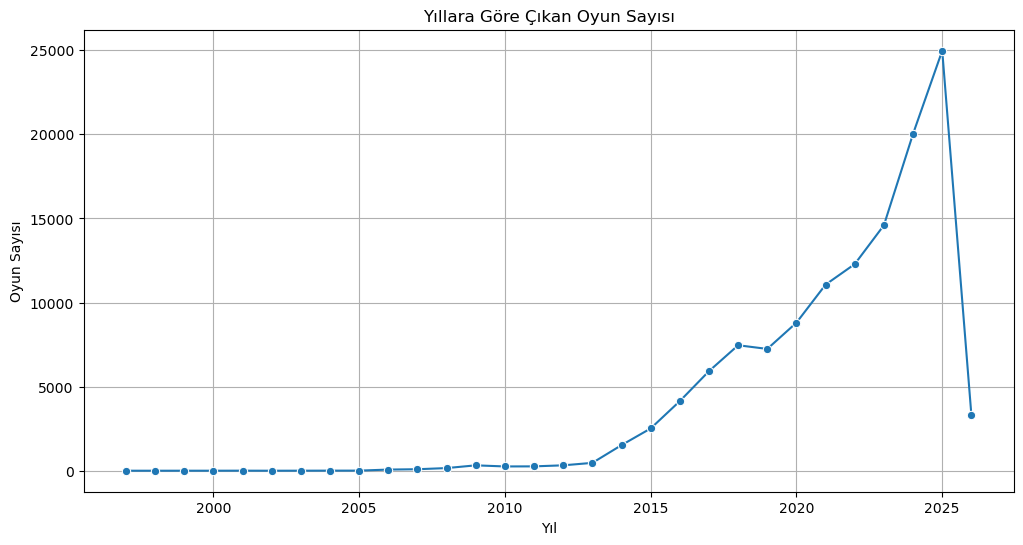

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Yıllara göre oyun sayısı (Hangi yıl kaç oyun çıkmış?)
yearly_counts = df['Release_Year'].value_counts().sort_index()

# Görselleştirme
plt.figure(figsize=(12, 6))
sns.lineplot(x=yearly_counts.index, y=yearly_counts.values, marker='o')
plt.title('Yıllara Göre Çıkan Oyun Sayısı')
plt.xlabel('Yıl')
plt.ylabel('Oyun Sayısı')
plt.grid(True)
plt.show()

/var/folders/tf/v1pvgprs6_nf0mrynxcmbs9r0000gn/T/ipykernel_13882/1394883292.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_counts.index, y=monthly_counts.values, palette='viridis')


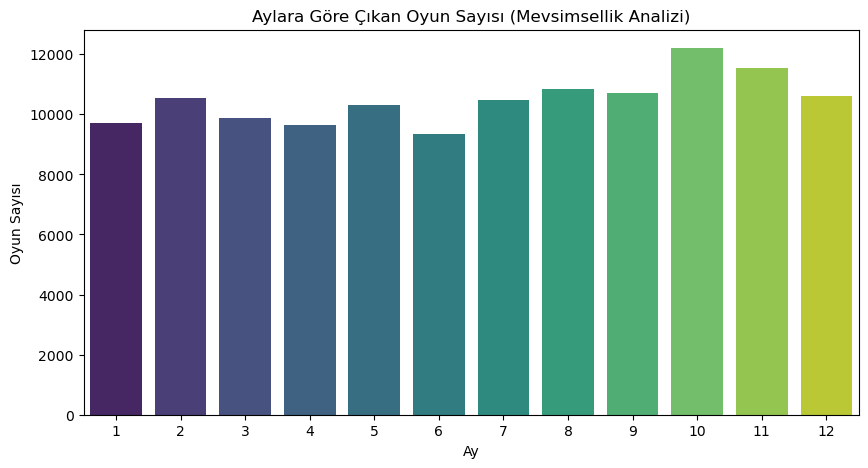

In [40]:
# Aylara göre oyun sayısı
monthly_counts = df['Release_Month'].value_counts().sort_index()

# Çubuk grafik (Bar plot) ile görselleştirme
plt.figure(figsize=(10, 5))
sns.barplot(x=monthly_counts.index, y=monthly_counts.values, palette='viridis')
plt.title('Aylara Göre Çıkan Oyun Sayısı (Mevsimsellik Analizi)')
plt.xlabel('Ay')
plt.ylabel('Oyun Sayısı')
plt.show()

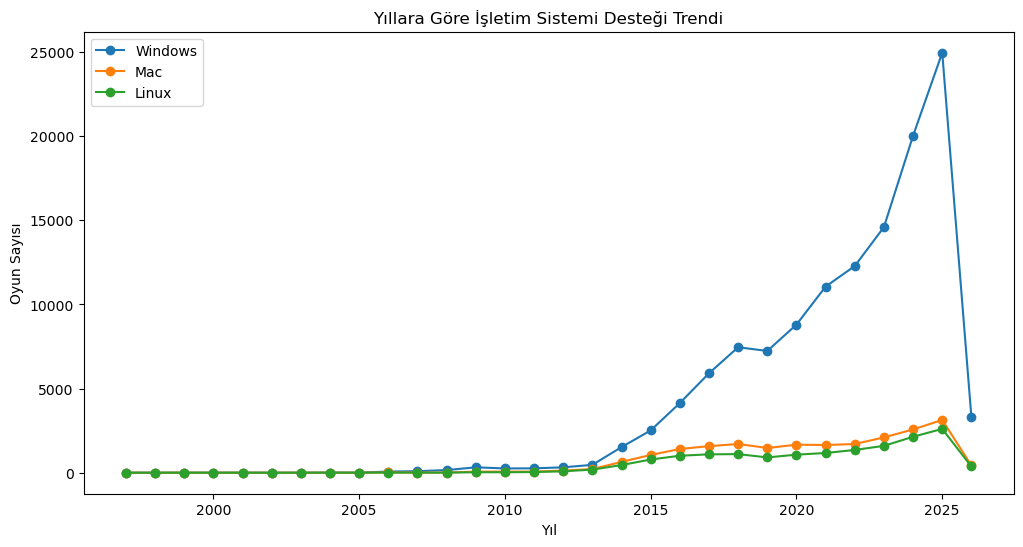

In [42]:
# Yıllara göre platform bazlı oyun sayıları
os_by_year = df.groupby('Release_Year')[['Windows', 'Mac', 'Linux']].sum()

os_by_year.plot(kind='line', figsize=(12, 6), marker='o')
plt.title('Yıllara Göre İşletim Sistemi Desteği Trendi')
plt.xlabel('Yıl')
plt.ylabel('Oyun Sayısı')
plt.show()

In [59]:
# Sadece Windows destekleyen oyunlar
only_windows = df[(df['Windows'] == True) & (df['Mac'] == False) & (df['Linux'] == False)]
print(f"Sadece Windows oyun sayısı: {len(only_windows)}")

# Tüm platformları (Win, Mac, Linux) aynı anda destekleyenler
all_platforms = df[(df['Windows'] == True) & (df['Mac'] == True) & (df['Linux'] == True)]
print(f"Tüm platformları destekleyen oyun sayısı: {len(all_platforms)}")

#windows desteklemeyen oyun var mı?
non_windows = 'Yok' if df['Windows'] is False else 'Var' + " " + str((df['Windows'] == False).sum())
print(f"Windows desteklemeyen oyun var mı: {non_windows}")

#linux desteklemeyen oyun var mı?
non_linux = 'Yok' if df['Linux'] is False else 'Var' + " " + str((df['Linux'] == False).sum())
print(f"Windows desteklemeyen oyun var mı: {non_linux}")

#mac desteklemeyen oyun var mı?
non_mac = 'Yok' if df['Mac'] is False else 'Var' + " " + str((df['Mac'] == False).sum())
print(f"Windows desteklemeyen oyun var mı: {non_mac}")

Sadece Windows oyun sayısı: 99601
Tüm platformları destekleyen oyun sayısı: 11532
Windows desteklemeyen oyun var mı: Var 44
Windows desteklemeyen oyun var mı: Var 109786
Windows desteklemeyen oyun var mı: Var 104136
